<a href="https://colab.research.google.com/github/salonapaliwal7/Machine-Learning-Projects/blob/main/Denoising_autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Denoising

In [14]:
import keras
from keras import layers
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt


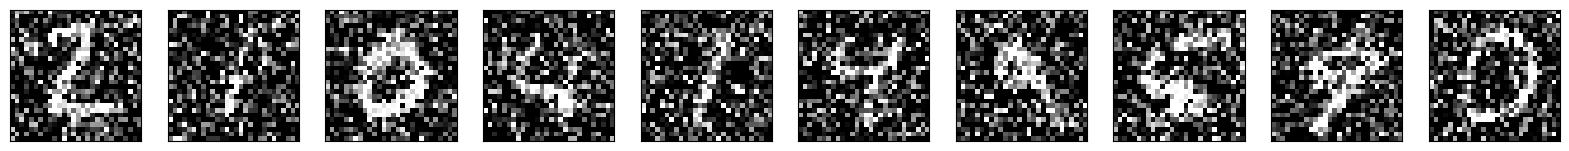

In [15]:
# import dataset
(x_train, y_train), (x_test,y_test) = mnist.load_data()

# normalize
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255


# reshape
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)


# add noise
noise = 0.5

# loc = mean of distribution , scale = std deviation
x_train_noisy = x_train + noise*np.random.normal(loc=0.0, scale=1.0,size=x_train.shape)
x_test_noisy = x_test + noise*np.random.normal(loc=0.0, scale=1.0,size=x_test.shape)

# deliberately adds noise :

# clip
x_train_noisy = np.clip(x_train_noisy, 0.,1.)
x_test_noisy = np.clip(x_test_noisy, 0.,1.)


# plot
n = 10
plt.figure(figsize=(20, 2))
for i in range(1, n + 1):
    ax = plt.subplot(1, n, i)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


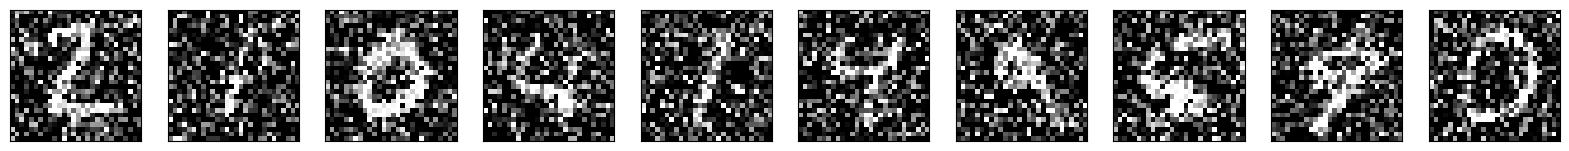

In [ ]:
# import dataset
(x_train, y_train), (x_test,y_test) = mnist.load_data()

# normalize
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255


# reshape
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)


# add noise
noise = 0.5

# loc = mean of distribution , scale = std deviation
x_train_noisy = x_train + noise*np.random.normal(loc=0.0, scale=1.0,size=x_train.shape)
x_test_noisy = x_test + noise*np.random.normal(loc=0.0, scale=1.0,size=x_test.shape)

# deliberately adds noise : Corrupt the input image with noise, but ask the model to reconstruct the original clean image.

# clip
x_train_noisy = np.clip(x_train_noisy, 0.,1.)
x_test_noisy = np.clip(x_test_noisy, 0.,1.)


# plot
n = 10
plt.figure(figsize=(20, 2))
for i in range(1, n + 1):
    ax = plt.subplot(1, n, i)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


In [25]:
# AutoEnocder model

input_img = keras.Input(shape=(784,))
encoded = layers.Dense(256, activation="relu")(input_img)
encoded = layers.Dense(64, activation="relu")(encoded)
encoded = layers.Dense(32, activation="relu")(encoded)

decoded = layers.Dense(64, activation="relu")(encoded)
decoded = layers.Dense(128, activation="relu")(decoded)
decoded = layers.Dense(784, activation="sigmoid")(decoded)



autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train_noisy, x_train,
                epochs=100,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))


# val_loss = meaning how well the model will perform on unseen data

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.2552 - val_loss: 0.1908
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1771 - val_loss: 0.1670
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1598 - val_loss: 0.1522
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1494 - val_loss: 0.1454
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1438 - val_loss: 0.1407
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1394 - val_loss: 0.1370
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1359 - val_loss: 0.1343
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1332 - val_loss: 0.1321
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1309 - val_loss: 0.1300
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1290 - val_loss: 0.1288
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1272 - val_loss: 0.1282
Epoch 12/100
235/235 ━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


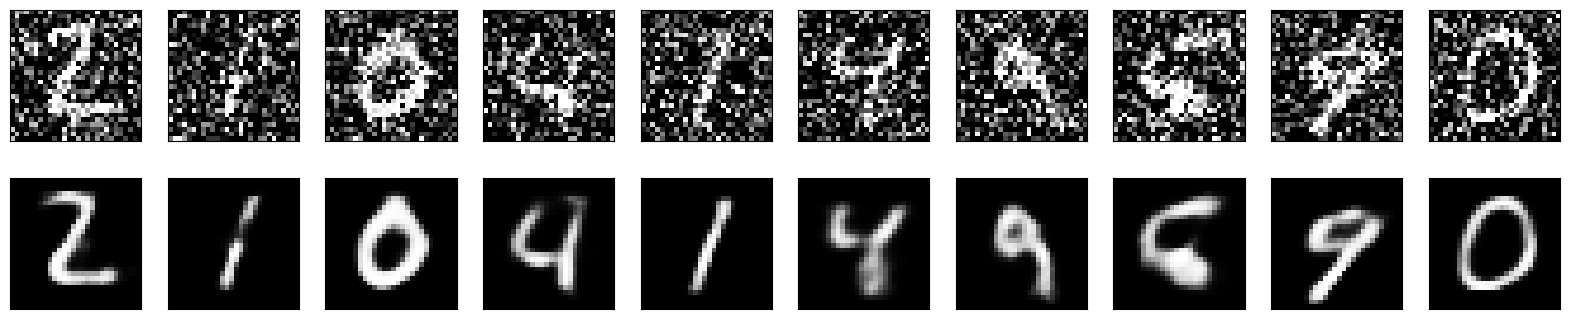

In [26]:
#Visualize the outputs

decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    # Display original
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()